In [2]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("CiferAI/Cifer-Fraud-Detection-Dataset-AF")

StatementMeta(, f3b37352-2e12-4d95-b7e9-54a2d8eb5f30, 4, Finished, Available, Finished, False)

Generating train split:   0%|          | 0/21000000 [00:00<?, ? examples/s]

StatementMeta(, f3b37352-2e12-4d95-b7e9-54a2d8eb5f30, 5, Finished, Available, Finished, False)

In [14]:
print(ds)

StatementMeta(, 9f8ec70e-3157-4fa9-9d7f-c2e31f3bc94d, 19, Finished, Available, Finished, False)

DatasetDict({
    train: Dataset({
        features: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
        num_rows: 21000000
    })
})


In [4]:
train_hf = ds["train"]
#display(train_hf)
#1 million rows first
#train_sample = train_hf.shuffle(seed=42).to_parquet('abfss://f8e3d19d-f7c2-4966-9804-d462790c6dac@onelake.dfs.fabric.microsoft.com/97dfca59-ee53-400b-9af8-f5cbd0eca69b/Files/Bronze')#.select(range(1_000_000))


StatementMeta(, f3b37352-2e12-4d95-b7e9-54a2d8eb5f30, 7, Finished, Available, Finished, False)

In [7]:
pdf = train_hf.to_pandas()
spark_df = spark.createDataFrame(pdf)

display(spark_df.tail(5))

StatementMeta(, f3b37352-2e12-4d95-b7e9-54a2d8eb5f30, 18, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 489fdf5f-8fef-4e9e-ae17-d08b176488a4)

In [8]:
spark_df.count()

StatementMeta(, f3b37352-2e12-4d95-b7e9-54a2d8eb5f30, 20, Finished, Available, Finished, False)

21000000

In [27]:
# Correlation matrix 
from pyspark.ml.feature import VectorAssembler as VA 
from pyspark.ml.stat import Correlation as corr

colns = [
    'amount', 
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'isFraud',
    'isFlaggedFraud'
]

assembler = VA(
    inputCols=colns,
    outputCol='features'
)

vector_df = assembler.transform(spark_df).select("features")

corr_matrix = corr.corr(vector_df, "features", "pearson")


StatementMeta(, fdc09b40-0f06-4b4e-9a14-d34cccb247ee, 30, Finished, Available, Finished, False)

DataFrame[pearson(features): matrix]


StatementMeta(, fdc09b40-0f06-4b4e-9a14-d34cccb247ee, 41, Finished, Available, Finished, False)

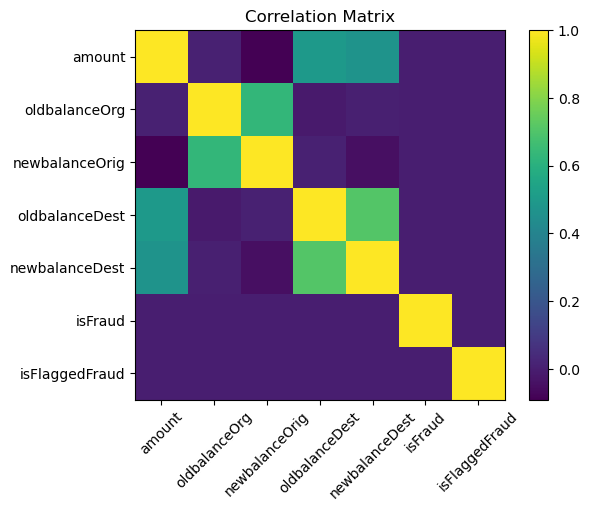

In [30]:
import matplotlib.pyplot as plt
import numpy as np

corr_array = corr_matrix.head()[0].toArray()

plt.figure()
plt.imshow(corr_array)
plt.colorbar()

plt.xticks(range(len(colns)), colns, rotation=45)
plt.yticks(range(len(colns)), colns)

plt.title("Correlation Matrix")
plt.show()

In [10]:
%%sql
DROP TABLE FraudDetection.dbo.Bronze

StatementMeta(, f3b37352-2e12-4d95-b7e9-54a2d8eb5f30, 22, Finished, Available, Finished, False)

<Spark SQL result set with 0 rows and 0 fields>

In [11]:
spark_df.write \
  .mode("overwrite") \
  .format("delta") \
  .saveAsTable("FraudDetection.dbo.Bronze")

StatementMeta(, f3b37352-2e12-4d95-b7e9-54a2d8eb5f30, 23, Finished, Available, Finished, False)

In [1]:
# Distribution of the legit and fraudulet transactions 

count_fraud = spark.table("CiferFraudDetection")

count_fraud.groupBy('isFraud').count().show()

# -> Imbalanced dataset : under sampling may help

StatementMeta(, 7247d2e6-8be1-4b48-b04e-15044554cd04, 3, Finished, Available, Finished, False)

+-------+------+
|isFraud| count|
+-------+------+
|      0|998700|
|      1|  1300|
+-------+------+



In [33]:
df = spark.sql("SELECT * FROM FraudDetection.dbo.Bronze LIMIT 1000")
display(df)

StatementMeta(, b1df87ee-6a55-4674-a0ce-b18c2f8805ae, 37, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 10e1c647-a4c6-40ba-9e06-3825f798c059)

In [1]:
from pyspark.sql import functions as F

# ===============================
# 0. Read the table from bronze layer
# ===============================
df = spark.sql("SELECT * FROM FraudDetection.dbo.Bronze LIMIT 1000")


# =========================
# 1. Separate label
# =========================
y_col = "isFraud"

# Drop leakage columns
df = df.drop("isFlaggedFraud")

# =========================
# 2. Balance features (VERY IMPORTANT)
# =========================
df = df.withColumn(
    "orig_balance_diff",
    F.col("oldbalanceOrg") - F.col("newbalanceOrig") - F.col("amount")
)

df = df.withColumn(
    "dest_balance_diff",
    F.col("newbalanceDest") - F.col("oldbalanceDest") - F.col("amount")
)

# =========================
# 3. Zero balance indicators
# =========================
df = df.withColumn(
    "orig_zero",
    (F.col("oldbalanceOrg") == 0).cast("int")
)

df = df.withColumn(
    "dest_zero",
    (F.col("oldbalanceDest") == 0).cast("int")
)

# =========================
# 4. Amount features
# =========================
df = df.withColumn(
    "log_amount",
    F.log1p(F.col("amount"))
)

df = df.withColumn(
    "amount_to_balance",
    F.col("amount") / (F.col("oldbalanceOrg") + F.lit(1))
)

# =========================
# 5. Error flags (VERY POWERFUL)
# =========================
df = df.withColumn(
    "orig_error",
    ((F.col("oldbalanceOrg") - F.col("amount")) != F.col("newbalanceOrig")).cast("int")
)

df = df.withColumn(
    "dest_error",
    ((F.col("oldbalanceDest") + F.col("amount")) != F.col("newbalanceDest")).cast("int")
)

# =========================
# 6. Extract entity type from names
# =========================
df = df.withColumn(
    "orig_name_type",
    F.substring(F.col("nameOrig"), 1, 1)
)

df = df.withColumn(
    "dest_name_type",
    F.substring(F.col("nameDest").cast('string'), 1, 1)
)


# =========================
# 7. Frequency features (IMPORTANT)
# =========================
orig_counts = df.groupBy("nameOrig").count().withColumnRenamed("count", "orig_freq")
dest_counts = df.groupBy("nameDest").count().withColumnRenamed("count", "dest_freq")

df = df.join(orig_counts, on="nameOrig", how="left")
df = df.join(dest_counts, on="nameDest", how="left")


# =========================
# 8. Pair frequency (VERY STRONG FEATURE)
# =========================
pair_counts = df.groupBy("nameOrig", "nameDest").count().withColumnRenamed("count", "pair_freq")

df = df.join(pair_counts, on=["nameOrig", "nameDest"], how="left")


# =========================
# Display the final result
# =========================
display(df.limit(10))

StatementMeta(, bc56cd49-863c-4a9e-8b0c-d560aa5adea4, 3, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 696b6c32-d394-4548-aa66-97df4fcbecaa)

In [3]:
df.write.mode('overwrite').format('delta').saveAsTable('FraudDetection.dbo.silver_layer_ciferFraudData')

StatementMeta(, bc56cd49-863c-4a9e-8b0c-d560aa5adea4, 6, Finished, Available, Finished, False)

In [30]:

# =========================
# 9. One-hot encode categorical columns
# =========================

# NOTE: In Spark, use StringIndexer + OneHotEncoder
from pyspark.ml.feature import StringIndexer, OneHotEncoder

categorical_cols = ["type", "orig_name_type", "dest_name_type"]

indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoder = OneHotEncoder(
    inputCols=[c + "_idx" for c in categorical_cols],
    outputCols=[c + "_ohe" for c in categorical_cols]
)



display(df)

StatementMeta(, b1df87ee-6a55-4674-a0ce-b18c2f8805ae, 34, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, d31146e0-d030-4d79-8f5d-7bbcf588a9c4)

In [4]:
# Count null values for each feature
from pyspark.sql.functions import col, sum as _sum

null_counts = count_fraud.select([
    _sum(col(c).isNull().cast("int")).alias(c)
    for c in count_fraud.columns
])

null_counts.show()

StatementMeta(, 63bbc946-c0d3-4209-84f7-486c4c5260f5, 17, Finished, Available, Finished, False)

+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|step|type|amount|nameOrig|oldbalanceOrg|newbalanceOrig|nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|   0|   0|     0|       0|            0|             0|       0|             0|             0|      0|             0|
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+



In [5]:
# NULL + NaN
from pyspark.sql.functions import isnan

null_nan_counts = count_fraud.select([
    _sum(
        col(c).isNull().cast("int") + isnan(col(c)).cast("int")
    ).alias(c)
    for c in count_fraud.columns
])

null_nan_counts.show()

StatementMeta(, 63bbc946-c0d3-4209-84f7-486c4c5260f5, 26, Finished, Available, Finished, False)

+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|step|type|amount|nameOrig|oldbalanceOrg|newbalanceOrig|nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|   0|   0|     0|       0|            0|             0|       0|             0|             0|      0|             0|
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+



In [2]:
# Get unique values for "type" column 

count_fraud.select('type').distinct().show()
count_fraud.select('nameOrig').distinct().count()

# should we consider 'nameOrig' as a categorical feature?

StatementMeta(, 7247d2e6-8be1-4b48-b04e-15044554cd04, 5, Finished, Available, Finished, False)

+--------+
|    type|
+--------+
|TRANSFER|
| CASH_IN|
|CASH_OUT|
| PAYMENT|
|   DEBIT|
+--------+



960603

In [9]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(
    inputCol="type",
    outputCol="type_idx",
    handleInvalid="keep"   # VERY important
)

df_indexed = indexer.fit(count_fraud).transform(count_fraud)

display(df_indexed)

StatementMeta(, 63bbc946-c0d3-4209-84f7-486c4c5260f5, 31, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 4167a090-5578-4919-930e-d4d3f15e0dd6)

In [11]:
from pyspark.ml.feature import OneHotEncoder

encoder = OneHotEncoder(
    inputCols=["type_idx"],
    outputCols=["type_encoded"]
)

df_encoded = encoder.fit(df_indexed).transform(df_indexed)

display(df_encoded)

# One hot encoding is not helping much.

StatementMeta(, 63bbc946-c0d3-4209-84f7-486c4c5260f5, 33, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 727a18ce-22e0-4176-af32-56b2aeed7dc6)

In [17]:
from pyspark.ml.feature import FeatureHasher
# Best for high cardinality :)
hasher = FeatureHasher(
    inputCols=["type"],
    outputCol="type_hashed",
    numFeatures=1024
)

df_hashed = hasher.transform(count_fraud)

display(df_hashed)

StatementMeta(, 63bbc946-c0d3-4209-84f7-486c4c5260f5, 39, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, c2914871-35e5-482d-b2ad-7234498bfd20)

In [18]:
from pyspark.ml import Pipeline

#Encoders and indexers should be part of a Pipeline to ensure consistent behavior in training and inference.


pipeline = Pipeline(stages=[
    StringIndexer(inputCol="type", outputCol="type_index", handleInvalid="keep"),
    OneHotEncoder(inputCol="type_index", outputCol="type_ohe")
])

df_transformed = pipeline.fit(count_fraud).transform(count_fraud)
display(df_transformed)

StatementMeta(, 63bbc946-c0d3-4209-84f7-486c4c5260f5, 40, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 581815f1-7588-4821-81e3-e9a3af09cd3c)

**Working with High Cardinality Columns**

- Target Encoding -> nameOrg -> avg(oldbalanceOrg + newbalanceOrg)
    - Use it for supervised learning

- Frequency Encoding: nameOrg -> cont of nameOrg
- Hash Encoding: It maps Strig values into a fixed number of columns
    - Use it for massive number of unique values and Streaming / large-scale data 

-Embeding: Convert string values to learned vectors
    - Best suited for deep learning models :)
- Label Encoding: If ordering is possible on the values (eg: fair < good < v good < excellent)

| Model Type                   | Recommended               |
|------------------------------|---------------------------|
| Linear / Logistic Regression | Target / Hash encoding    |
| Tree models (XGBoost, RF)    | Label or Target encoding  |
| Deep learning                | Embeddings                |
| Unknown / baseline           | Frequency encoding        |


In [ ]:
# Is there any relation (patern) between receiver and sender ...